### **Proyecto:** Clasificación - Bank Marketing  
### **Dataset:** [Bank Marketing - UCI ML Repository](https://archive.ics.uci.edu/dataset/222/bank+marketing)  
### **Objetivo:** Predecir cual perfil de cliente presenta mayor probabilidad a suscribir un depósito a plazo fijo (`y` = Alta probabilidad, Media y Baja), para reducir costes de las campañas de marketing.
---
### 🎯 ¿Por qué este dataset?
### El dataset Bank Marketing recoge datos reales de campañas de marketing telefónico de un banco portugués.  
### Es un problema de **clasificación**: queremos predecir cual perfil de cliente presenta mayor probabilidad a contratar un depósito a plazo.  
### Tiene 45.211 registros y 16 variables de entrada, lo que lo hace suficientemente grande para entrenar modelos robustos.
---

### **1. Cargar dataset y importar librerias**

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [24]:
df= pd.read_csv("../data/raw/bank-full.csv", sep= ";")

### **2. Visualizar DataFrame y tipos de datos**

In [25]:
# Visualizar 5 primeras filas del dataset
df.head(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [26]:
# Visualizar 5 últimas filas del dataset
df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no


In [27]:
# Visualizar cantidad de lineas y columnas del dataset
df.shape

(45211, 17)

In [28]:
# Info general del dataset (tipos de datos)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [29]:
# Visualiza la descripcion de la distribuicion de las varibales cuantitativas (numericas)
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [30]:
# Visualiza la descripcion de la distribuicion de las varibales cualitativas (categoricas)
df.select_dtypes(include='str').describe()


,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


In [31]:
# Visualiza la presencia de valores nulos en el dataset
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

,Cantidad unknown,% del total
poutcome,36959.0,81.75
contact,13020.0,28.80
education,1857.0,4.11
job,288.0,0.64



 Estas columnas tienen valores 'unknown' que deberán tratarse en el preprocesamiento.


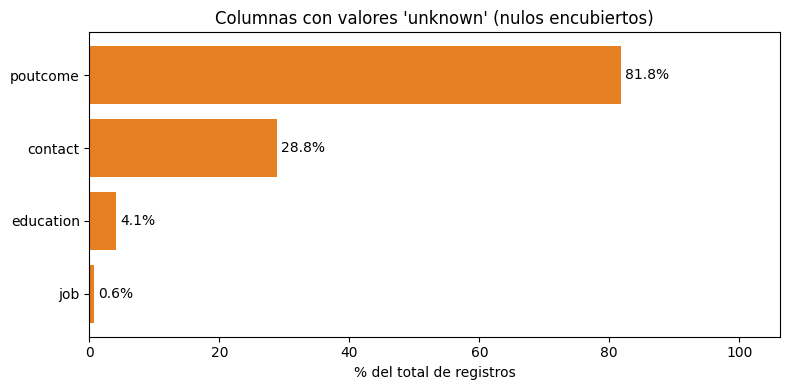

In [32]:
# Visualiza los valores nulos encubiertos como 'unknown'
# Tabla
cols_categoricas = df.select_dtypes(include='str').columns
unknown_counts = {}
for col in cols_categoricas:
    n_unknown = (df[col] == 'unknown').sum()
    pct = round(n_unknown / len(df) * 100, 2)
    if n_unknown > 0:
        unknown_counts[col] = {'Cantidad unknown': n_unknown, '% del total': pct}
if unknown_counts:
    display(pd.DataFrame(unknown_counts).T.sort_values('Cantidad unknown', ascending=False))
    print("\n Estas columnas tienen valores 'unknown' que deberán tratarse en el preprocesamiento.")
else:
    print("No se encontraron valores 'unknown' en columnas categóricas.")

# Gráfico
if unknown_counts:
    unk_df = pd.DataFrame(unknown_counts).T.reset_index()
    unk_df.columns = ['Columna', 'Cantidad', 'Porcentaje']
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.barh(unk_df['Columna'], unk_df['Porcentaje'], color='#e67e22')
    ax.bar_label(bars, labels=[f"{v:.1f}%" for v in unk_df['Porcentaje']], padding=3)
    ax.set_xlabel('% del total de registros')
    ax.set_title("Columnas con valores 'unknown' (nulos encubiertos)")
    ax.set_xlim(0, unk_df['Porcentaje'].max() * 1.3)
    plt.tight_layout()
    plt.show()

In [33]:
# Visualizar presencia de valores duplicados
n_duplicados = df.duplicated().sum()
print(f'  Filas duplicadas : {n_duplicados:,}')

  Filas duplicadas : 0


---
#### CONCLUSION DE LA EXPLORACIÓN INICIAL
---
#### 🔑 Hallazgos principales:
| # | Hallazgo | Impacto | Acción recomendada |
|---|----------|---------|--------------------|
| 1 | El dataset tiene **45.211 filas y 17 columnas** | Dataset amplio y suficiente para ML | Ninguna |
| 2 | **No hay valores NaN reales**, pero hay `'unknown'` en varias columnas | Nulos encubiertos | Tratar en preprocesamiento: imputar o crear categoría propia |
| 3 | La columna `contact` tiene el mayor % de `'unknown'` | Media-alta | Evaluar si imputar o eliminar |
| 4 | La columna `pdays` tiene valor -1 para clientes no contactados anteriormente | Valor especial | Crear una variable binaria `fue_contactado_antes` |
| 5 | `duration` es la última duración de llamada — **dato que no se conoce antes de hacer la llamada** | Data leakage potencial | Evaluar si incluirla o excluirla del modelo |
| 6 | No se detectaron columnas tipo ID ni filas duplicadas | ✅ | Ninguna |
---
#### ⚠️ Puntos críticos:
##### **1. La columna `duration` es problemática:**  
##### Indica la duración de la última llamada en segundos. El problema es que **no se puede conocer antes de hacer la llamada**, así que usarla para predecir si el cliente va a suscribir sería hacer trampa (data leakage). El equipo debe decidir si excluirla del modelo o mantenerla con esta advertencia documentada.
##### **2. Los valores `'unknown'`:**  
##### En lugar de NaN reales, este dataset usa la cadena `'unknown'` para indicar información desconocida. En el preprocesamiento hay que decidir si tratarlos como una categoría más o imputarlos con la moda de cada columna.
---

### **3. Analisis Univariado**
#### 3.1 Variable Objectivo - 'y'

🎯 Distribución de la variable objetivo:



,Cantidad,Porcentaje (%)
y,,
no,39922,88.3
yes,5289,11.7


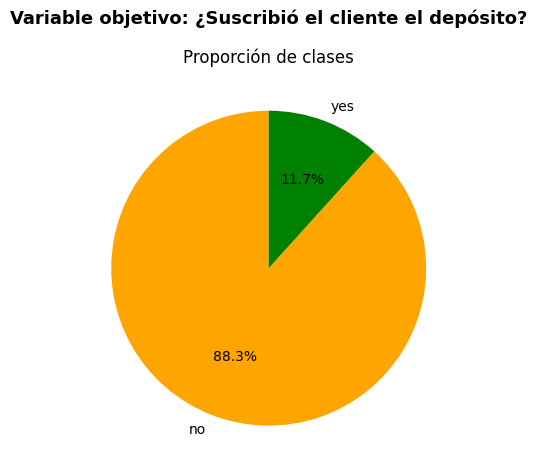


⚠️ DESBALANCEO DETECTADO: ratio 7.5:1 entre clases.
→ Considerar técnicas de balanceo en el preprocesamiento (SMOTE, class_weight, etc.)


In [34]:
target_col = 'y'   # ← nombre de la variable objetivo
conteo = df[target_col].value_counts()
porcentaje = df[target_col].value_counts(normalize=True).mul(100).round(2)
print('🎯 Distribución de la variable objetivo:\n')
resumen_target = pd.DataFrame({'Cantidad': conteo, 'Porcentaje (%)': porcentaje})
display(resumen_target)

# Gráfico circular
plt.pie(conteo.values, labels=conteo.index, autopct='%1.1f%%', colors=['orange', 'green'], startangle=90)
plt.title('Proporción de clases')
plt.suptitle('Variable objetivo: ¿Suscribió el cliente el depósito?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
ratio = conteo.max() / conteo.min()
if ratio > 3:
    print(f'\n⚠️ DESBALANCEO DETECTADO: ratio {ratio:.1f}:1 entre clases.')
    print('→ Considerar técnicas de balanceo en el preprocesamiento (SMOTE, class_weight, etc.)')
else:
    print(f'\n✅ Las clases están razonablemente balanceadas (ratio {ratio:.1f}:1).')

#### 3.2 Variables Categoricas

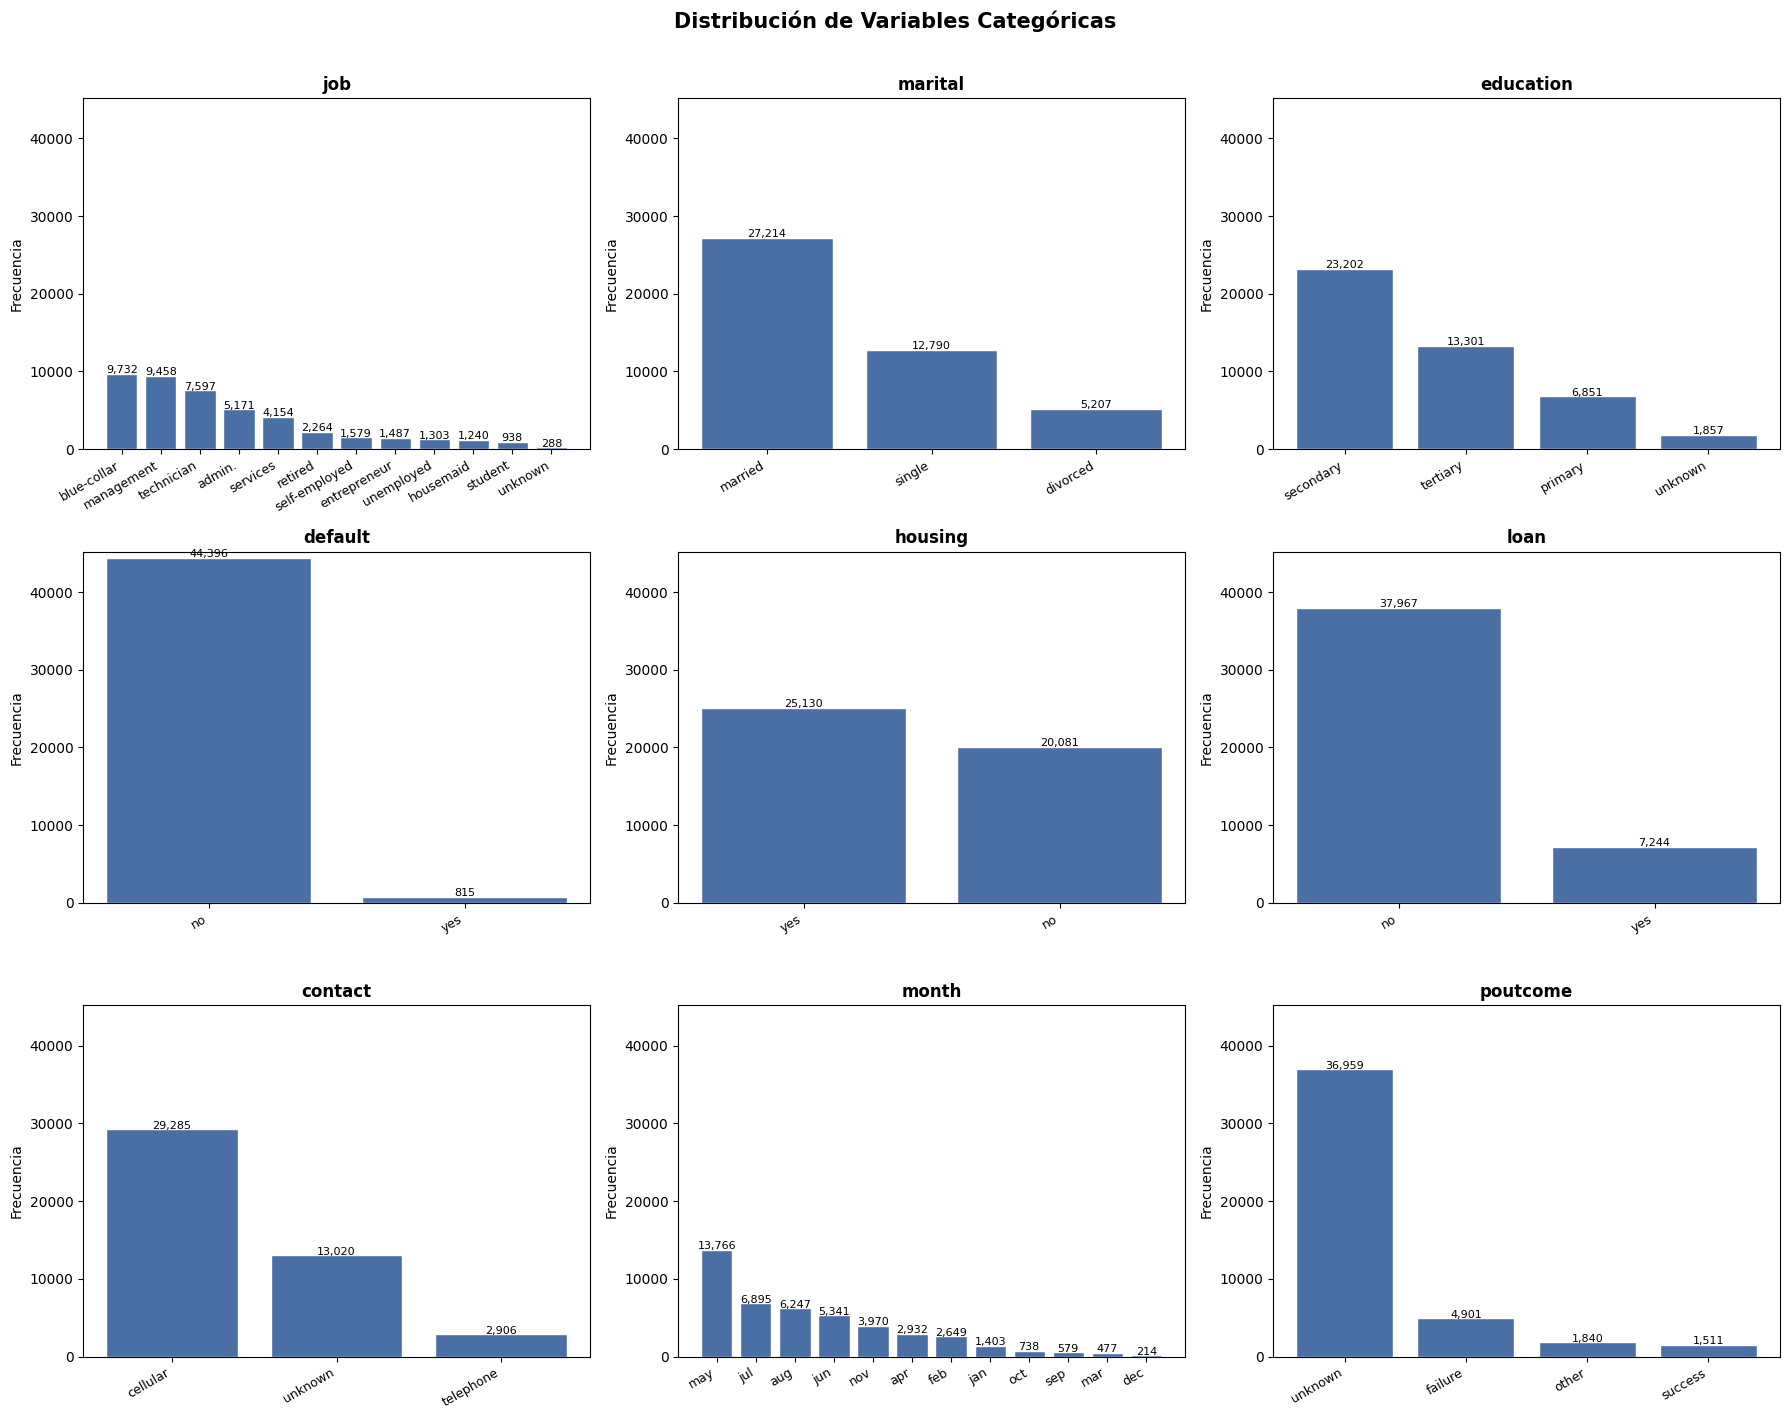

In [35]:
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))

for ax, col in zip(axes.flat, cat_cols):
    counts = df[col].value_counts()
    bars = ax.bar(range(len(counts)), counts.values, color='#4A6FA5',
                  edgecolor='white', linewidth=1)
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=30, ha='right', fontsize=9)
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Frecuencia')
    ax.set_ylim(0, len(df)) 
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{val:,}', ha='center', fontsize=8)

plt.suptitle('Distribución de Variables Categóricas', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Se analiza la distribución de las 9 variables categóricas del dataset.
Los hallazgos más relevantes son:

| Variable | Hallazgo | Implicación |
|----------|----------|-------------|
| `job` | `blue-collar` y `management` dominan (~43% entre los dos) | Alta diversidad, requiere One-Hot Encoding |
| `marital` | 60% casados (`married`) | Distribución desigual pero manejable |
| `education` | `secondary` representa el 51% | Posible encoding ordinal (primary < secondary < tertiary) |
| `default` | 98.2% `no` - clase casi única | Poca varianza, candidata a eliminación |
| `housing` | Distribución relativamente equilibrada (56% `yes`) | Útil para el modelo |
| `loan` | 84% `no` - muy desbalanceada | Baja varianza, evaluar su aporte |
| `contact` | 28.8% `unknown` - medio de contacto no registrado | `unknown` es informativo, no eliminar |
| `month` | `may` concentra el 30% de los contactos | Estacionalidad fuerte, puede ser relevante |
| `poutcome` | 81.7% `unknown` - sin campaña previa | `unknown` = "cliente nuevo", mantener como categoría |

#### 3.3 Variables Númericas

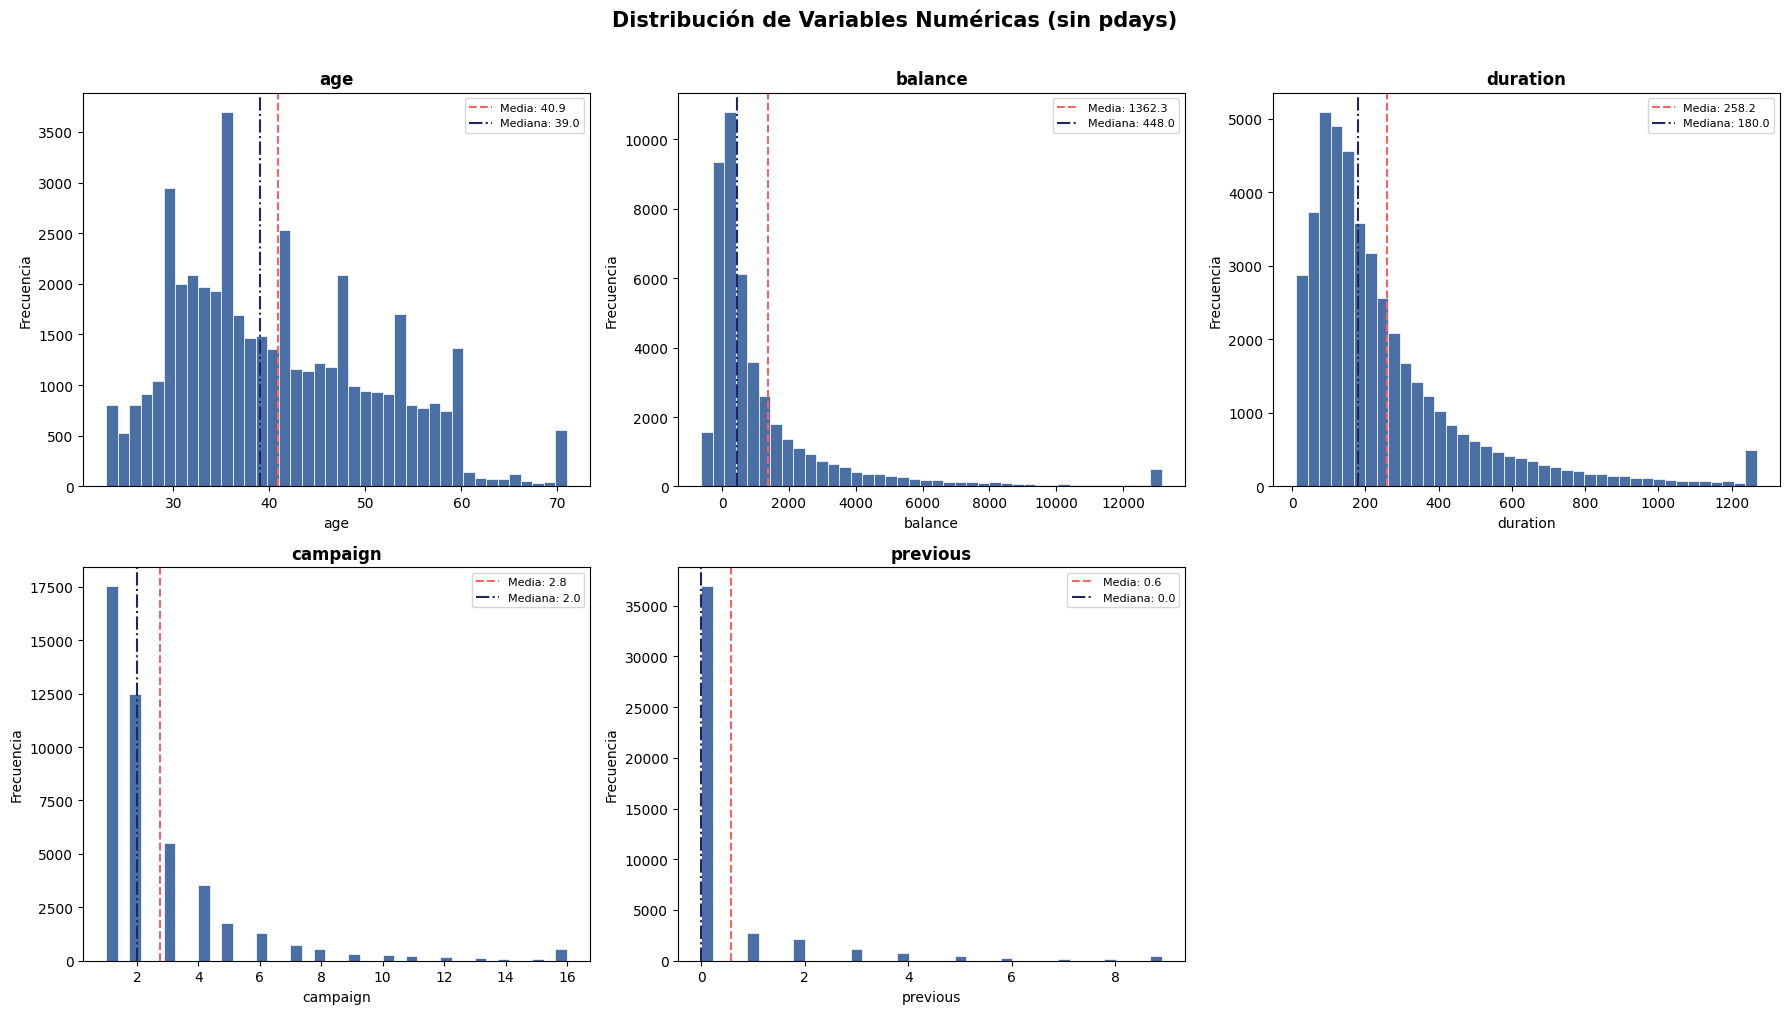

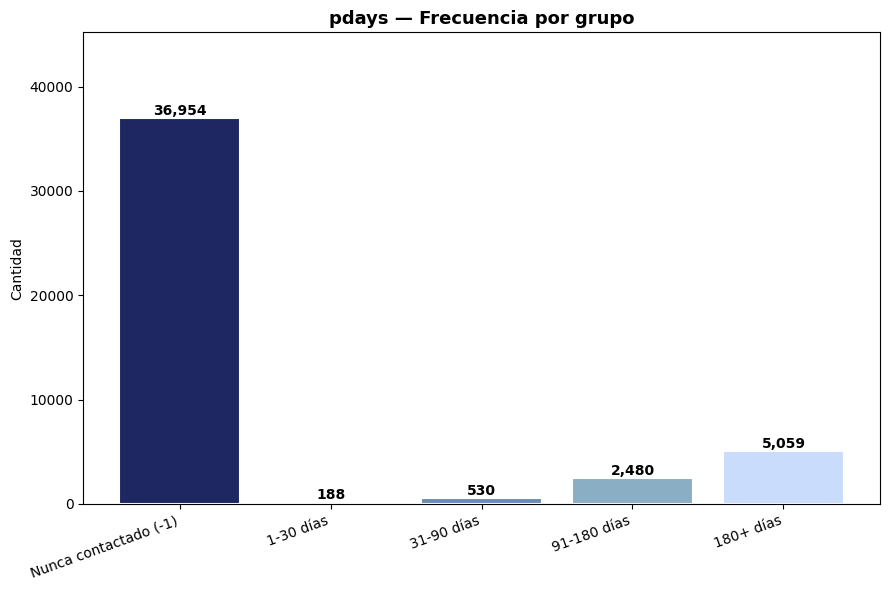

In [36]:
num_cols = ['age', 'balance', 'duration', 'campaign', 'previous']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flat, num_cols):
    data = df[col].clip(df[col].quantile(0.01), df[col].quantile(0.99))
    ax.hist(data, bins=40, color='#4A6FA5', edgecolor='white', linewidth=0.5)
    ax.axvline(df[col].mean(), color='#F96167', linestyle='--',
               linewidth=1.5, label=f'Media: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='#1E2761', linestyle='-.',
               linewidth=1.5, label=f'Mediana: {df[col].median():.1f}')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

# 6th box (empty)
axes[1, 2].set_visible(False)

plt.suptitle('Distribución de Variables Numéricas (sin pdays)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show() 

# El gráfico de la variable 'pdays'

df['y_bin'] = (df['y'] == 'yes').astype(int)
df['pdays_grupo'] = df['pdays'].apply(lambda x: 'Nunca contactado (-1)' if x == -1
                                      else ('1-30 días'   if x <= 30
                                      else ('31-90 días'  if x <= 90
                                      else ('91-180 días' if x <= 180
                                      else '180+ días'))))

orden = ['Nunca contactado (-1)', '1-30 días', '31-90 días', '91-180 días', '180+ días']

counts = df['pdays_grupo'].value_counts().reindex(orden)
colors = ['#1E2761', '#4A6FA5', '#6B8DB5', '#8AAFC5', '#CADCFC']

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(range(len(orden)), counts.values, color=colors,
              edgecolor='white', linewidth=1.5)
ax.set_xticks(range(len(orden)))
ax.set_xticklabels(orden, rotation=20, ha='right', fontsize=10)
ax.set_ylim(0, len(df))
ax.set_ylabel('Cantidad')
ax.set_title('pdays — Frecuencia por grupo', fontweight='bold', fontsize=13)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f'{val:,}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

#### Hallazgos principales

| Variable | Hallazgo | Implicación |
|-----------|------------|---------------|
| `age` | Ligera asimetría positiva. | No requiere transformación urgente. |
| `balance` | Fuerte asimetría y outliers altos. | Aplicar log-transform o Robust Scaling. |
| `duration` | Asimetría positiva marcada. | Variable clave; posible transformación. |
| `campaign` | Concentración en valores bajos (1–3). | Distribución sesgada; revisar extremos. |
| `previous` | Predomina el valor 0. | Puede binarizarse (0 vs >0). |
| `pdays` | Fuerte desbalance. 36,954 clientes nunca contactados (`-1`). | tratar como variable categórica o separar en binaria (contactado sí/no). |



---

### 4. Análisis Bivariante
En esta sección analizamos cómo se relaciona cada variable independiente directamente con la variable objetivo (y). Esto nos permitirá identificar qué características tienen mayor poder predictivo individualmente.

#### 4.1. Variables Categóricas vs. Target (Tasa de Conversión)
Calcularemos la proporción de "yes" para cada categoría para ver qué perfiles son más propensos a contratar el depósito.

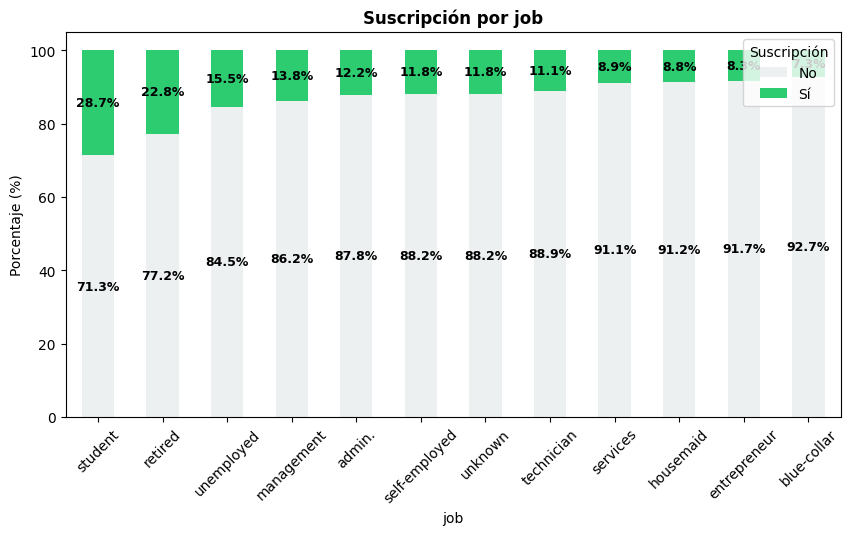

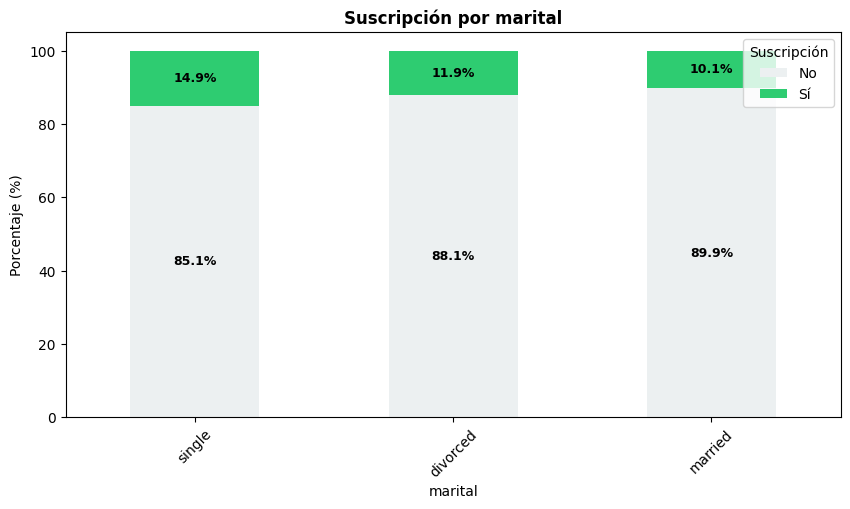

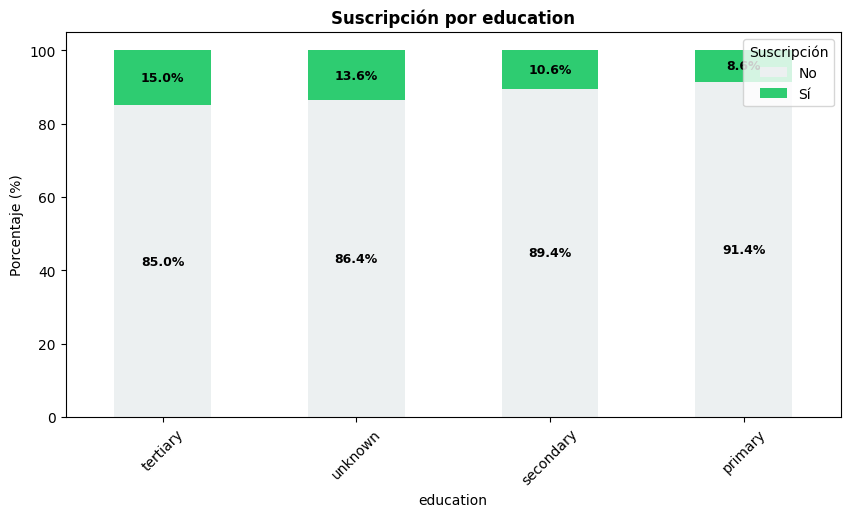

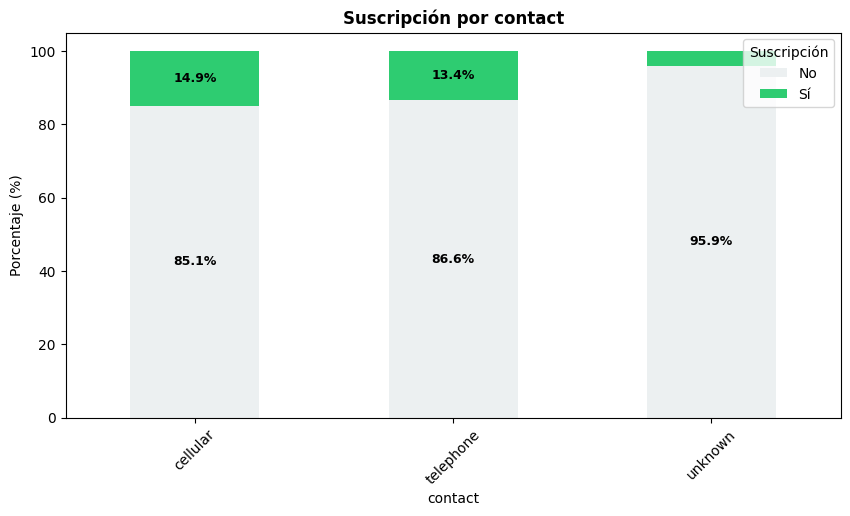

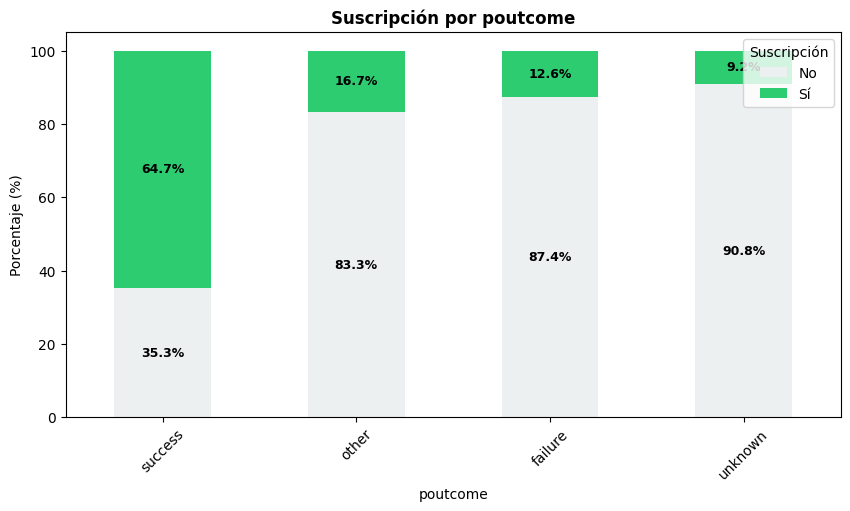

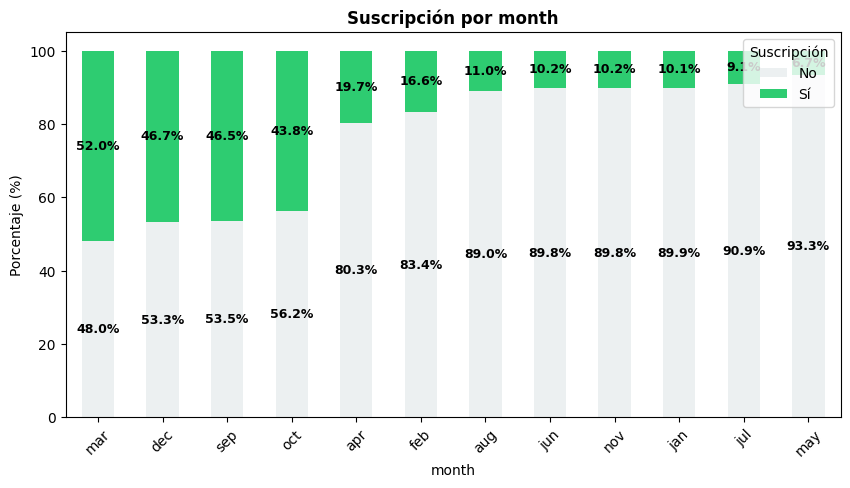

In [37]:
def plot_bivariate_cat(df, col, target='y'):
    # Calcular porcentajes de suscripción por categoría
    temp_df = pd.crosstab(df[col], df[target], normalize='index') * 100
    temp_df = temp_df.sort_values(by='yes', ascending=False)
    
    ax = temp_df.plot(kind='bar', stacked=True, figsize=(10, 5), color=['#ecf0f1', '#2ecc71'])
    plt.title(f'Suscripción por {col}', fontweight='bold')
    plt.ylabel('Porcentaje (%)')
    plt.xlabel(col)
    plt.legend(title='Suscripción', labels=['No', 'Sí'], loc='upper right')
    plt.xticks(rotation=45)
    
    # Añadir etiquetas de texto
    for p in ax.patches:
        width, height = p.get_width(), p.get_height()
        if height > 5: # Solo mostrar si el porcentaje es significativo
            ax.annotate(f'{height:.1f}%', (p.get_x() + width/2, p.get_y() + height/2), 
                        ha='center', va='center', fontsize=9, color='black', fontweight='bold')
    plt.show()

# Lista de variables categóricas clave para analizar
cols_to_plot = ['job', 'marital', 'education', 'contact', 'poutcome', 'month']

for col in cols_to_plot:
    plot_bivariate_cat(df, col)

#### 4.1.2. Asociación entre variables categóricas (Cramér's V)
Antes de avanzar al análisis multivariante, es fundamental entender si nuestras variables independientes están relacionadas entre sí. Utilizaremos el coeficiente de Cramér's V para medir la fuerza de asociación entre variables categóricas.

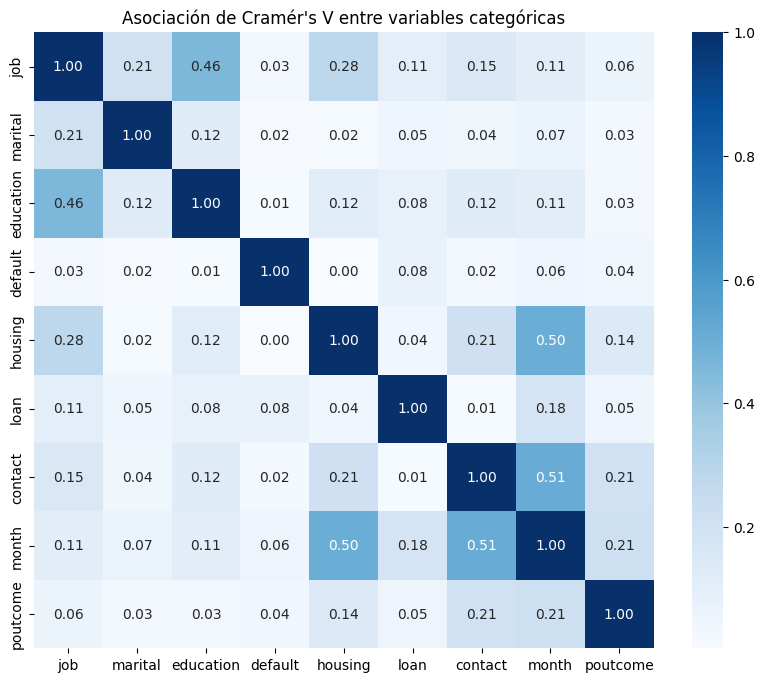

In [38]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

cat_vars = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
matrix = np.zeros((len(cat_vars), len(cat_vars)))

for i, v1 in enumerate(cat_vars):
    for j, v2 in enumerate(cat_vars):
        matrix[i, j] = cramers_v(df[v1], df[v2])

plt.figure(figsize=(10, 8))
sns.heatmap(pd.DataFrame(matrix, index=cat_vars, columns=cat_vars), annot=True, cmap='Blues', fmt=".2f")
plt.title("Asociación de Cramér's V entre variables categóricas")
plt.show()

**Interpretación del Análisis Bivariante Categórico:**

* **Job:** Los estudiantes (student) y jubilados (retired) tienen las tasas de conversión más altas, lo cual sugiere que el ciclo de vida y la disponibilidad de tiempo influyen.
* **Poutcome:** El éxito en campañas anteriores (success) es el predictor más fuerte; casi el 65% de quienes aceptaron antes, vuelven a aceptar.
* **Month:** Meses como marzo, septiembre, octubre y diciembre muestran tasas de éxito muy superiores a la media, posiblemente por ser meses con menos saturación de llamadas.
* **Contact:** Los contactos por cellular son mucho más efectivos que por telephone o unknown.


#### 4.2. Análisis de Variables Numéricas vs. Target (Densidad y Distribución)

Debido a la alta dispersión y presencia de valores atípicos (outliers) en variables como `balance` y `campaign`, utilizamos gráficos de densidad (KDE) y escalas optimizadas. Esto nos permite observar dónde se concentra realmente la masa de clientes que suscriben (`yes`) frente a los que no (`no`).

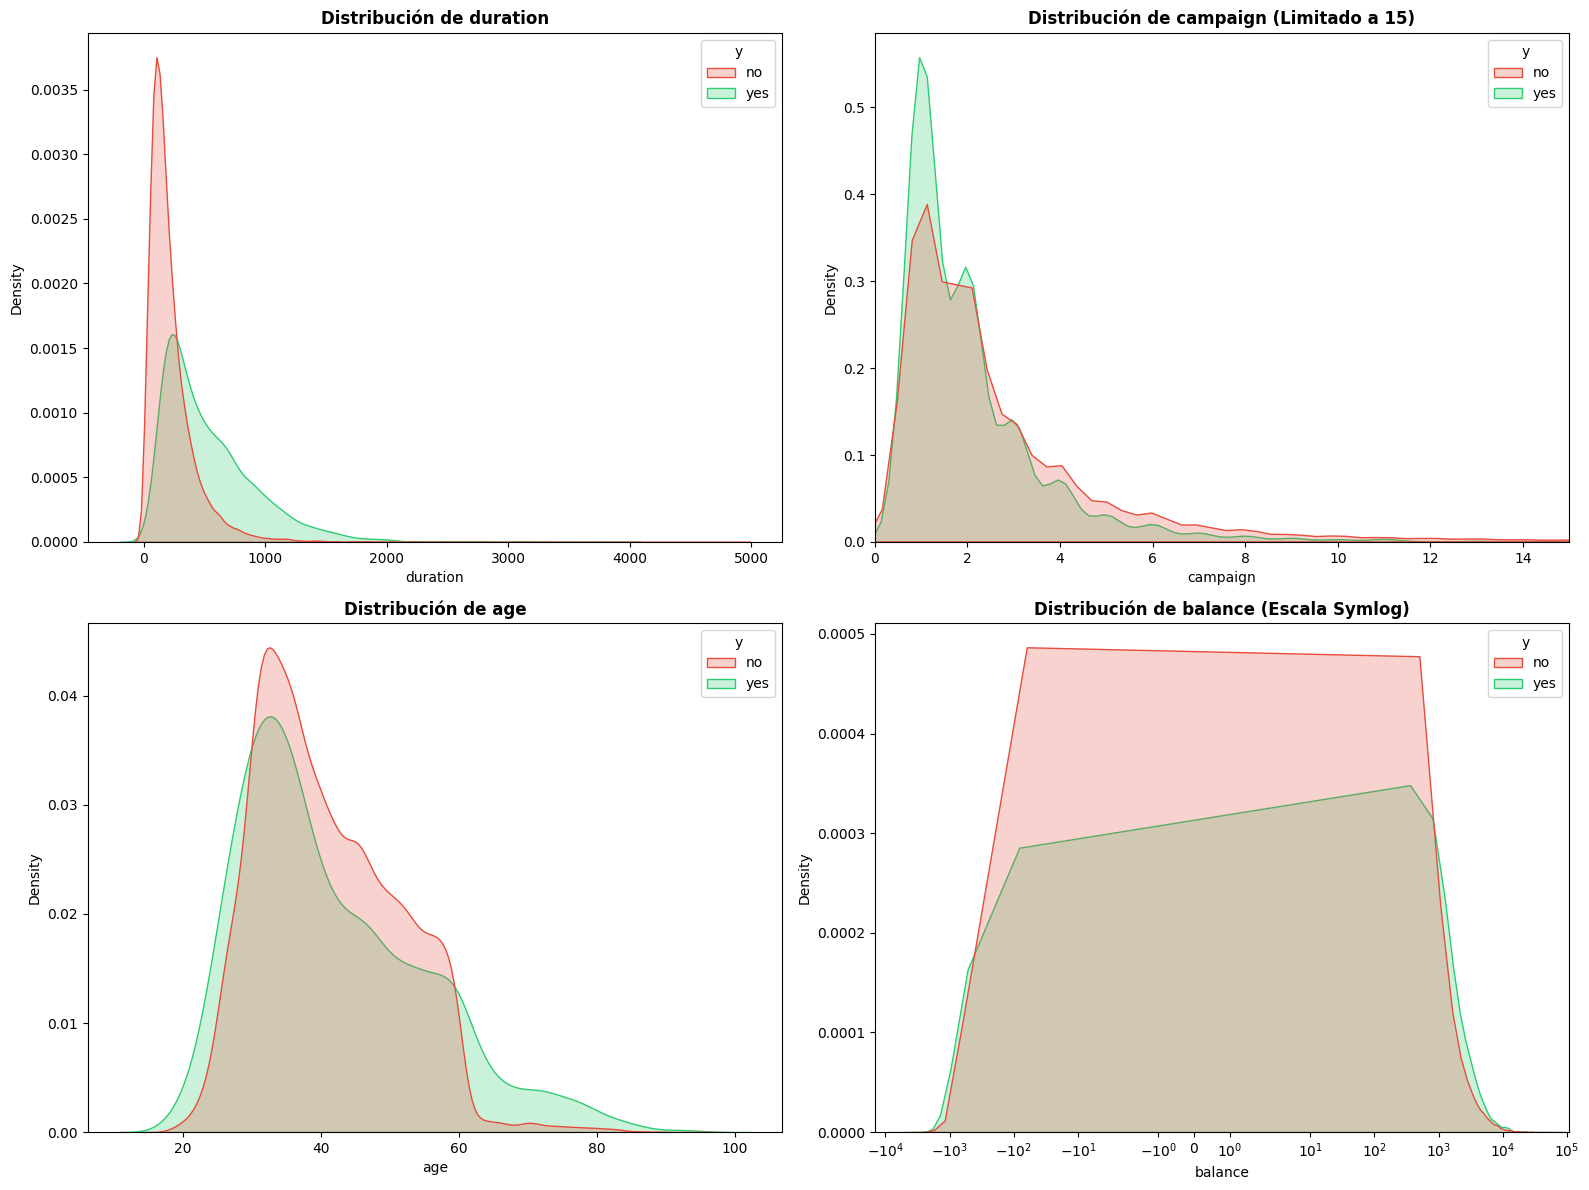

In [17]:
# Variables a analizar según la interpretación
num_cols = ['duration', 'campaign', 'age', 'balance']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    if col == 'balance':
        # Para balance usamos escala symlog por los valores negativos y extremos
        sns.kdeplot(data=df, x=col, hue='y', fill=True, ax=axes[i], palette={'no': '#e74c3c', 'yes': '#2ecc71'}, common_norm=False)
        axes[i].set_xscale('symlog')
        axes[i].set_title(f'Distribución de {col} (Escala Symlog)', fontweight='bold')
    elif col == 'campaign':
        # Limitamos visualmente campaign para ver el detalle de 1-10 contactos
        sns.kdeplot(data=df, x=col, hue='y', fill=True, ax=axes[i], palette={'no': '#e74c3c', 'yes': '#2ecc71'}, common_norm=False)
        axes[i].set_xlim(0, 15)
        axes[i].set_title(f'Distribución de {col} (Limitado a 15)', fontweight='bold')
    else:
        sns.kdeplot(data=df, x=col, hue='y', fill=True, ax=axes[i], palette={'no': '#e74c3c', 'yes': '#2ecc71'}, common_norm=False)
        axes[i].set_title(f'Distribución de {col}', fontweight='bold')

plt.tight_layout()
plt.show()

**Interpretación del Análisis Bivariante Numérico:**

* **Duration:** Como se sospechaba, existe una diferencia abismal. Las llamadas más largas tienden a terminar en "yes". (Confirmamos que es data leakage para el modelo preventivo, ya que este dato solo se conoce después de la llamada).
* **Campaign:** Se observa que a mayor número de contactos en esta campaña, menor es la probabilidad de éxito. La densidad de "yes" cae drásticamente después de 3 contactos; el cliente se satura.
* **Age:** No parece haber una diferencia de mediana clara, aunque la densidad muestra que los extremos (muy jóvenes y muy mayores) suelen decir que sí con más frecuencia, como vimos en la variable `job`.
* **Balance:** Aunque hay mucha dispersión por los outliers, los clientes con saldos medios-altos (observados en la escala logarítmica) parecen tener una ligera tendencia positiva hacia la suscripción en comparación con los saldos negativos o en cero.

---

### 5. Análisis Multivariante
En esta sección exploramos cómo interactúan dos o más variables simultáneamente con el objetivo de encontrar segmentos de clientes específicos.

#### 5.1 Interacción Edad, Saldo y Éxito
Queremos ver si la relación entre la edad y el saldo bancario varía para los clientes que aceptan el depósito.

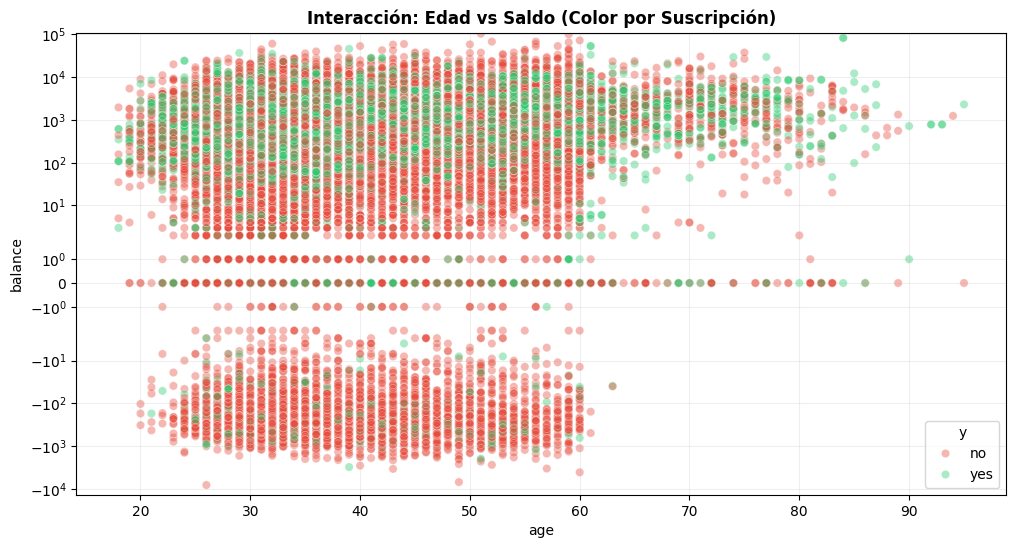

In [18]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='age', y='balance', hue='y', alpha=0.4, palette={'yes': '#2ecc71', 'no': '#e74c3c'})
plt.yscale('symlog')
plt.title('Interacción: Edad vs Saldo (Color por Suscripción)', fontweight='bold')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

**Interpretación:**
El gráfico de dispersión muestra que los éxitos (`yes`) no están limitados a un rango de edad específico, pero hay una concentración notable en saldos positivos. La escala logarítmica nos permite ver que los clientes con saldos negativos (deudas) rara vez aceptan el depósito, independientemente de su edad.

#### 5.2. Estacionalidad y Éxito por Mes
Analizaremos si el mes de contacto y el hecho de tener una hipoteca influyen conjuntamente en la decisión.

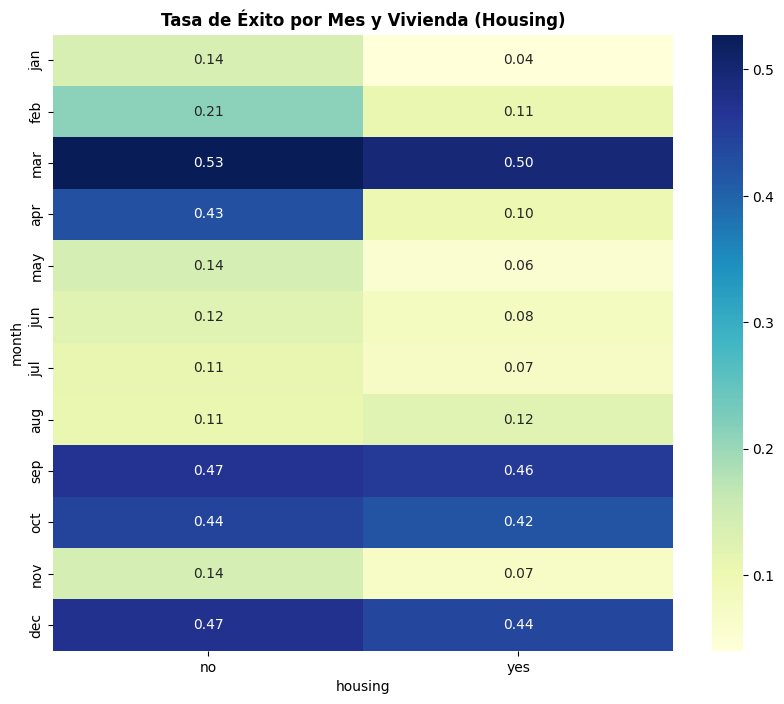

In [19]:
# Crear una tabla pivote para el heatmap
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
pivot_table = df.pivot_table(index='month', columns='housing', values='y_bin', aggfunc='mean').reindex(month_order)

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Tasa de Éxito por Mes y Vivienda (Housing)', fontweight='bold')
plt.show()

**Interpretación:**
Este análisis revela algo sorprendente: los meses de marzo, septiembre, octubre y diciembre tienen tasas de éxito excepcionalmente altas (hasta 0.60+), a pesar de que (como vimos en el análisis univariado) son los meses con menos llamadas. Esto sugiere que las campañas en esos meses son mucho más selectivas y efectivas. Además, en casi todos los meses, los clientes sin hipoteca (`housing`=`no`) rinden mejor.

#### 5.3 Segmentación por Trabajo y Educación
¿Cómo influye el nivel educativo dentro de cada categoría laboral en la suscripción?

C:\Users\SONY VAIO\AppData\Local\Temp\ipykernel_1428\361482331.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='job', y='y_bin', hue='education', palette='viridis', ci=None)


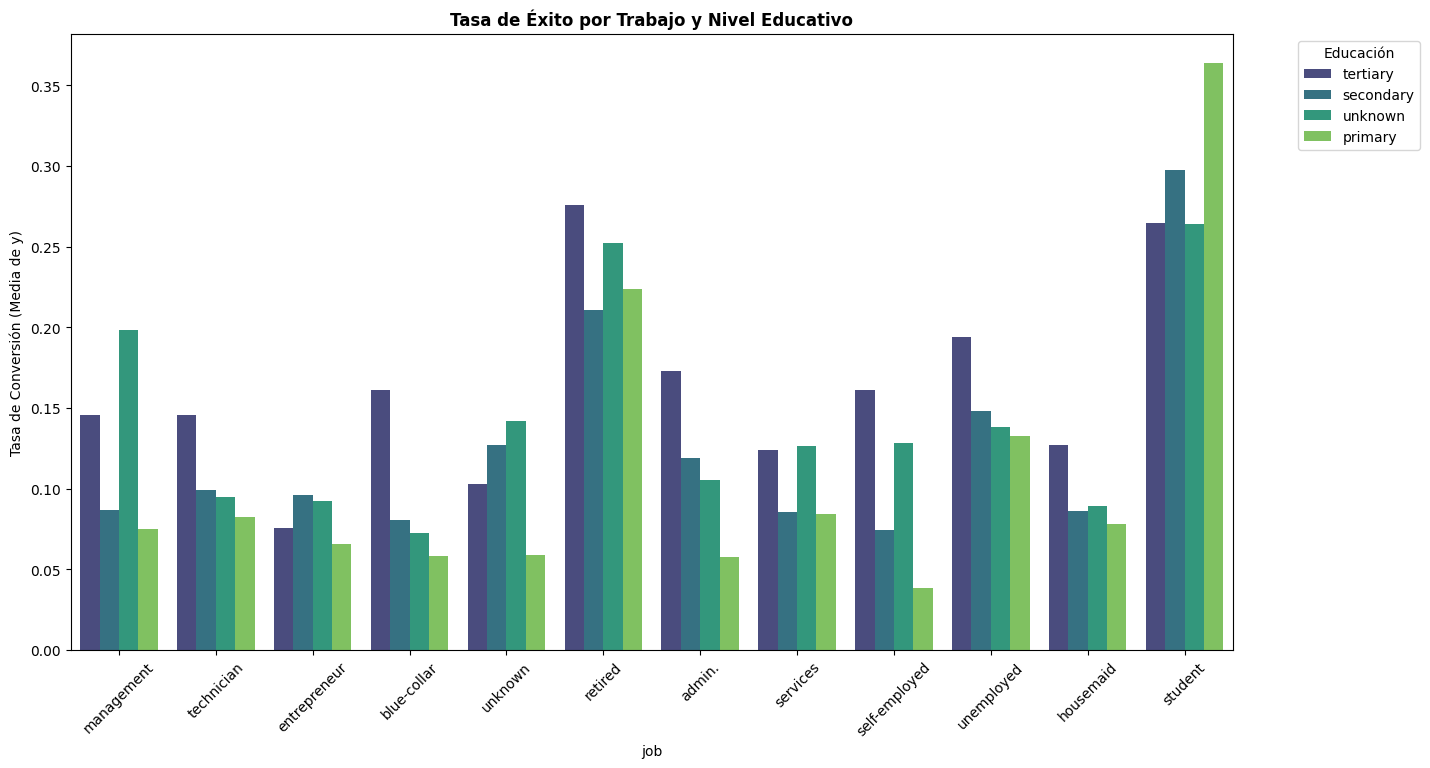

In [20]:
plt.figure(figsize=(15, 8))
# Filtrar para ver solo la tasa de éxito (media de y_bin)
sns.barplot(data=df, x='job', y='y_bin', hue='education', palette='viridis', ci=None)
plt.title('Tasa de Éxito por Trabajo y Nivel Educativo', fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Tasa de Conversión (Media de y)')
plt.legend(title='Educación', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

**Interpretación:**
1. En casi todas las profesiones, el nivel educativo terciario aumenta la probabilidad de éxito.
2. Destaca el grupo de estudiantes con educación secundaria, que presentan una tasa de conversión muy alta.
3. Los jubilados mantienen una tasa de éxito alta independientemente de su nivel educativo, lo que los convierte en un segmento objetivo muy estable.

#### 5.4. Análisis del perfil financiero: Balance y Préstamos
¿Cómo influye la solvencia económica en la decisión? Analizamos la tasa de conversión combinando el saldo bancario (dividido en quartiles) con la presencia de préstamos.

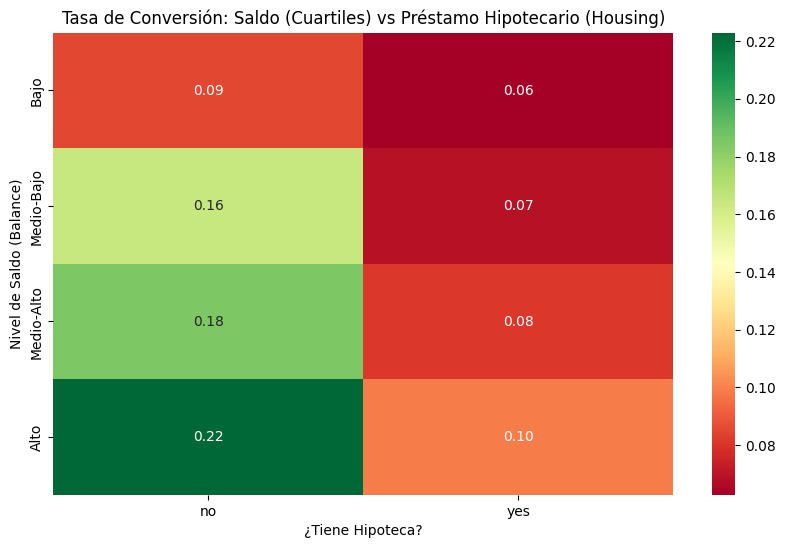

In [21]:
# Crear una variable de cuartiles de balance para facilitar la visualización
df['balance_quartile'] = pd.qcut(df['balance'], 4, labels=['Bajo', 'Medio-Bajo', 'Medio-Alto', 'Alto'])

# Analizar la tasa de conversión por cuartil de balance y tipo de préstamo
pivot_loan = df.pivot_table(index='balance_quartile', columns='housing', values='y_bin', aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_loan, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Tasa de Conversión: Saldo (Cuartiles) vs Préstamo Hipotecario (Housing)')
plt.xlabel('¿Tiene Hipoteca?')
plt.ylabel('Nivel de Saldo (Balance)')
plt.show()

#### 5.5. Segmentación: Clientes Nuevos vs. Clientes Previos
Dado que la mayoría de los clientes no han sido contactados anteriormente (pdays = -1), es crucial comparar su comportamiento frente a aquellos que ya conocen el banco.

C:\Users\SONY VAIO\AppData\Local\Temp\ipykernel_1428\430597348.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='is_new_customer', y='y_bin', palette='muted')


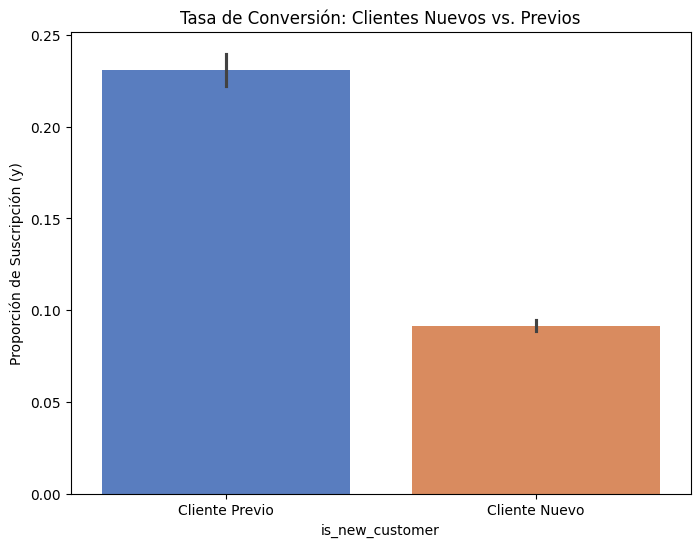

In [22]:
df['is_new_customer'] = (df['pdays'] == -1).astype(int)

plt.figure(figsize=(8, 6))
sns.barplot(data=df, x='is_new_customer', y='y_bin', palette='muted')
plt.xticks([0, 1], ['Cliente Previo', 'Cliente Nuevo'])
plt.title('Tasa de Conversión: Clientes Nuevos vs. Previos')
plt.ylabel('Proporción de Suscripción (y)')
plt.show()

## Conclusiones finales del EDA y Recomendaciones para el Modelo
Tras el análisis exhaustivo, estas son las conclusiones clave para la fase de modelado:

1. **Variables Críticas:** `poutcome` (éxito previo), `month` (estacionalidad), `housing` (hipoteca) y `job` (estudiantes/jubilados) parecen ser los predictores más potentes.
2. **El problema de `duration`:** El análisis bivariado confirmó que es la variable más correlacionada, pero siguiendo el objetivo de negocio (predicción antes de la llamada), debe ser eliminada. El modelo deberá aprender a predecir basándose en el perfil del cliente y no en la duración de la interacción actual.
3. **Desbalanceo de Clases:** Solo un ~11% de los clientes suscribe el depósito. Será necesario aplicar técnicas como SMOTE o ajustar los pesos de las clases (class_weight) durante el entrenamiento del modelo.
4. **Ingeniería de Variables (Feature Engineering):**
* `pdays`: Debe ser binarizada o agrupada, ya que el valor -1 distorsiona la media.
* `month`: Podría agruparse en "Temporada Alta/Baja" de conversión según lo visto en el heatmap.
* `balance`: Requiere un escalado robusto debido a la gran cantidad de outliers.
5. **Tratamiento de 'Unknown':** En variables como poutcome y contact, el valor 'unknown' es en sí mismo una categoría informativa que no debe eliminarse, ya que suele identificar a clientes nuevos o sin historial.